In [2]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


run_number =51
# --- Parametri modificabili ---
X_TARGET = 5.0
Y_TARGET = 5.0

# Molteplicità per ogni detector — cambia solo questi!
MULT_DET0 = 1   # minimo hit detector 0
MULT_DET1 = 1   # minimo hit detector 1
MULT_DET2 = 0   # detector 2: whatever (0 = nessun vincolo)

# ------------------------------

branch_list = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude', 'Waveform',
    'ArraySize', 'xCoord', 'yCoord', 'Multiplicity',
    'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude',
    'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open(f"~/Scrivania/sampic_run{run_number}_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=5_000)):
        n_chunk = len(chunk)

        array_size = ak.to_numpy(chunk['ArraySize'])     # (n_chunk,)
        mult       = ak.to_numpy(chunk['Multiplicity'])  # (n_chunk, 140)

        # xCoord e yCoord sono uguali per tutte le hit dell'evento, prendi la prima
        xcoord = ak.to_numpy(chunk['xCoord'])[:, 0]
        ycoord = ak.to_numpy(chunk['yCoord'])[:, 0]

        # --- Filtro evento ---
        mask_evento = (
            (((xcoord == X_TARGET) & (ycoord == Y_TARGET))|((xcoord == 0.5) & (ycoord==1)) &
            (mult[:, 0] == MULT_DET0) &
            (mult[:, 1] == MULT_DET1) &
            (mult[:, 2] >= MULT_DET2)   # se MULT_DET2=0 è sempre True
            )|(True)
        )

        #mask provvisoria
        mask_evento = ((xcoord != 9) & (ycoord != 5))
        if mask_evento.sum() == 0:
            continue

        n_sel = mask_evento.sum()
        array_size_filt = array_size[mask_evento]
        mult_filt       = mult[mask_evento]

        # --- Branch 2D ---
        arr_2d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_2d}
        rows_2d = {k: [] for k in arr_2d}
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for k in arr_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])
        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in arr_2d})

        # --- Waveform ---
        waveform_raw = ak.to_numpy(chunk['Waveform'])[mask_evento]
        waveforms = []
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for hit in range(n_hit):
                waveforms.append(waveform_raw[evt, hit, :])
        df_2d['Waveform'] = waveforms

        # --- Branch 1D ---
        arr_1d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size_filt) for k in branch_1d})

        # --- Multiplicity come colonne separate ---
        df_mult = pd.DataFrame({
            'Mult_det1': np.repeat(mult_filt[:, 0], array_size_filt),
            'Mult_det2': np.repeat(mult_filt[:, 1], array_size_filt),
            'Mult_det3': np.repeat(mult_filt[:, 2], array_size_filt),
        })

        # --- Indice evento originale ---
        idx_originali = np.where(mask_evento)[0] + i * 5_000
        event_idx = np.repeat(idx_originali, array_size_filt)

        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi selezionati: {n_sel} — hit totali: {len(df_chunk)}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(50))
titoli = {1: 'DAVIDE', 2: 'GOLIA', 3: '7PAD'}

Chunk 1 — eventi selezionati: 4594 — hit totali: 10040
Chunk 2 — eventi selezionati: 4550 — hit totali: 9016
Chunk 3 — eventi selezionati: 4489 — hit totali: 8982
Chunk 4 — eventi selezionati: 4502 — hit totali: 8987
Chunk 5 — eventi selezionati: 4520 — hit totali: 9464
Chunk 6 — eventi selezionati: 4523 — hit totali: 9363
Chunk 7 — eventi selezionati: 4505 — hit totali: 9197
Chunk 8 — eventi selezionati: 4549 — hit totali: 8731
Chunk 9 — eventi selezionati: 3018 — hit totali: 6516
Chunk 10 — eventi selezionati: 497 — hit totali: 672
Chunk 11 — eventi selezionati: 384 — hit totali: 483
Chunk 12 — eventi selezionati: 2606 — hit totali: 5707
Chunk 13 — eventi selezionati: 2187 — hit totali: 4804
Chunk 14 — eventi selezionati: 656 — hit totali: 858
Chunk 15 — eventi selezionati: 744 — hit totali: 1096
Chunk 16 — eventi selezionati: 3035 — hit totali: 9592
Chunk 17 — eventi selezionati: 1273 — hit totali: 2023
Chunk 18 — eventi selezionati: 598 — hit totali: 704
Chunk 19 — eventi seleziona

In [3]:
df['Waveform'] = df['Waveform'].apply(lambda wf: np.delete(wf, 63)) # sample corrotto, lo elimino

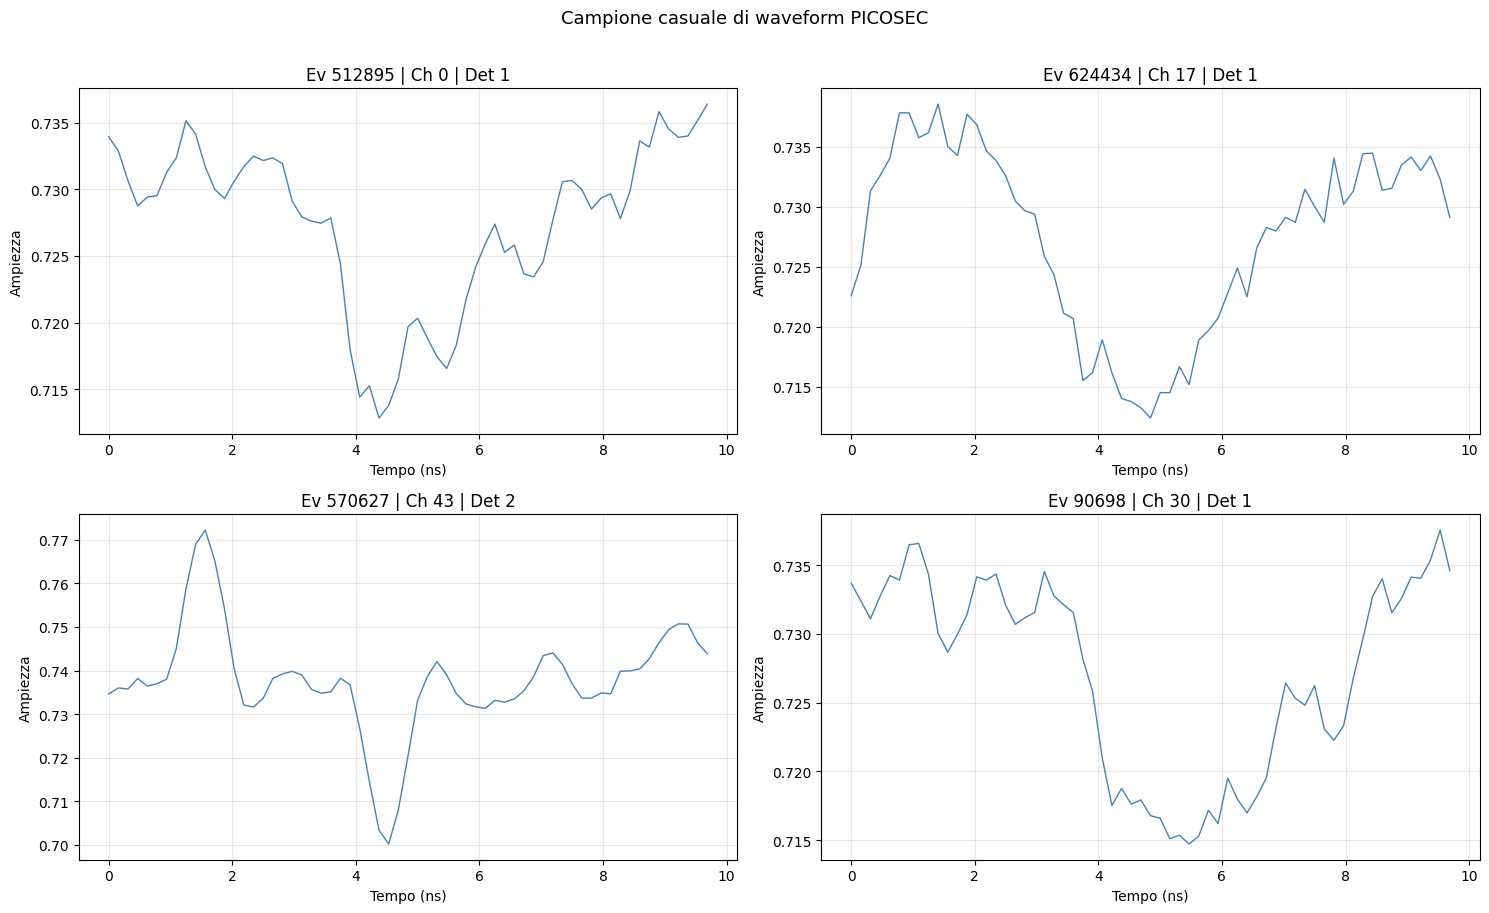

In [4]:
#plot random wvaeform with amplitude >-0.02
# Plotta 9 waveform a caso per farsi un'idea visiva
df_example=df.copy()
df_example = df_example[df_example["Amplitude"]>-0.02]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Campiona 9 righe casuali
sample = df_example.sample(4, random_state=5).reset_index(drop=True)

for idx, ax in enumerate(axes.flat):
    riga = sample.iloc[idx]
    wf   = riga['Waveform']
    t_ns = np.arange(len(wf)) * (1/6.4)  # converti sample → ns
    
    ax.plot(t_ns, wf, color='steelblue', lw=1)
    #ax.axhline(float(riga['baseline']), color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_xlabel("Tempo (ns)")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Ev {int(riga['event_idx'])} | Ch {int(riga['Channel'])} | Det {int(riga['Detector'])}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Campione casuale di waveform PICOSEC", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
df= df[df['Amplitude']<-0.02]

   event_idx  Channel  Detector  integrale  ampiezza  rise_time  fwhm
0          0       48       2.0  -0.381995 -0.022078        5.0  17.0
1          1       44       2.0  -0.390650 -0.025849        5.0  14.0
2          3        7       3.0  -1.487505 -0.089607        5.0  15.0
3          6        1       3.0  -3.178457 -0.222839        5.0  12.0
4          7       48       2.0  -0.805932 -0.043975        5.0  18.0
5          8       15       2.0  -0.707787 -0.046698        6.0  14.0
6          8       53       2.0  -0.498920 -0.032477        5.0  14.0
7          8       51       2.0  -0.488147 -0.025559        7.0  18.0
8         10       40       2.0  -0.479035 -0.032373        6.0  15.0
9         13        2       3.0  -0.325947 -0.024533        5.0  11.0


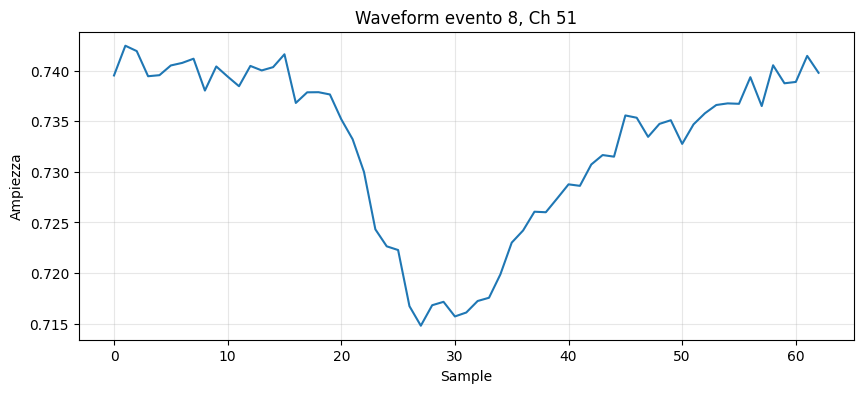

Min: 0.71480936
Max: 0.7424469
Media primi 10 sample (baseline): 0.7403688


In [5]:

df= df[df['Amplitude']<-0.02]
def analizza_waveform(wf, n_baseline=10):
    """
    n_baseline = quante sample iniziali usare per stimare la baseline
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = wf - baseline  # segnale centrato a zero (i punti a riposo oscillano intorno a 0)

    # --- Picco (minimo perché segnale negativo) ---
    idx_picco = np.argmin(wf_corr)
    ampiezza  = np.min(wf_corr)  # valore negativo (es. -100)

    # Se l'impulso è praticamente inesistente (solo rumore), restituisci NaN per evitare calcoli errati
    if ampiezza >= -1e-3: # adatta questa soglia al tuo rumore di fondo
        return {
            'baseline'  : baseline, 'integrale' : 0, 'ampiezza'  : ampiezza,
            'idx_picco' : idx_picco, 'rise_time' : np.nan, 'fwhm'      : np.nan,
        }

    # --- Integrale (carica) ---
    integrale = np.trapezoid(wf_corr)  # sarà negativo

    # --- Tempo di salita (10% → 90% del picco, andando verso il basso) ---
    soglia_10 = 0.10 * ampiezza  # es. -10
    soglia_90 = 0.90 * ampiezza  # es. -90
    
    try:
        # Fronte di discesa (dall'inizio al picco)
        fronte_salita = wf_corr[:idx_picco]
        
        # Cerchiamo partendo dal picco e tornando indietro (invertendo l'array con [::-1])
        # Vogliamo il primo punto che, tornando a zero, supera (diventa più vicino a zero, quindi >) la soglia
        idx_t90_retro = np.where(fronte_salita[::-1] >= soglia_90)[0][0]
        t90 = (idx_picco - 1) - idx_t90_retro
        
        idx_t10_retro = np.where(fronte_salita[::-1] >= soglia_10)[0][0]
        t10 = (idx_picco - 1) - idx_t10_retro
        
        rise_time = t90 - t10
        if rise_time <= 0: rise_time = np.nan
            
    except IndexError:
        rise_time = np.nan

    # --- FWHM ---
    soglia_half = 0.50 * ampiezza # es. -50
    try:
        # t_left: stessa logica del t90 (cerchiamo a ritroso dal picco)
        idx_left_retro = np.where(fronte_salita[::-1] >= soglia_half)[0][0]
        t_left = (idx_picco - 1) - idx_left_retro
        
        # t_right: guardiamo dal picco fino alla fine del segnale
        fronte_discesa = wf_corr[idx_picco:]
        # Cerchiamo in avanti il primo punto che risale sopra la metà ampiezza (diventa > di -50, es. -45)
        idx_right_avanti = np.where(fronte_discesa >= soglia_half)[0][0]
        t_right = idx_picco + idx_right_avanti
        
        fwhm = t_right - t_left
        if fwhm <= 0: fwhm = np.nan
    except IndexError:
        fwhm = np.nan

    return {
        'baseline'  : baseline,
        'integrale' : integrale,
        'ampiezza'  : ampiezza,
        'idx_picco' : idx_picco,
        'rise_time' : rise_time,
        'fwhm'      : fwhm,
    }

# Applica a tutto il DataFrame
features = df['Waveform'].apply(analizza_waveform)
df_feat  = pd.DataFrame(features.tolist())
df       = pd.concat([df.reset_index(drop=True), df_feat], axis=1)

print(df[['event_idx', 'Channel', 'Detector', 'integrale', 'ampiezza', 'rise_time', 'fwhm']].head(10))

plt.figure(figsize=(10,4))
plt.plot(df['Waveform'].iloc[7])  # uso iloc[1] che ha ampiezza più grande
plt.grid(True, alpha=0.3)
plt.ylabel("Ampiezza")
plt.xlabel("Sample")
plt.title(f"Waveform evento {df['event_idx'].iloc[7]}, Ch {int(df['Channel'].iloc[7])}")
plt.show()

print("Min:", df['Waveform'].iloc[7].min())
print("Max:", df['Waveform'].iloc[7].max())
print("Media primi 10 sample (baseline):", df['Waveform'].iloc[7][:10].mean())

In [6]:
#plot rand

In [7]:
#keeping only good waveform
df_good = df.copy() # per sicurezza, così non modifico df originale
df_good = df[(df['rise_time'] < 10) & (df['integrale'] >-20)]
print(f"Eventi con rise time < 10 sample e integrale < -20: {len(df_good)}")
print(df_good[['event_idx', 'Channel', 'Detector', 'integrale', 'rise_time']].head())

Eventi con rise time < 10 sample e integrale < -20: 400601
   event_idx  Channel  Detector  integrale  rise_time
0          0       48       2.0  -0.381995        5.0
1          1       44       2.0  -0.390650        5.0
2          3        7       3.0  -1.487505        5.0
3          6        1       3.0  -3.178457        5.0
4          7       48       2.0  -0.805932        5.0


In [8]:
from scipy.optimize import curve_fit

def sigmoid_neg(x, x0, k):
    """Sigmoide normalizzata tra 0 e 1"""
    return 1 / (1 + np.exp(-k * (x - x0)))

def fit_sigmoid_2p(wf, idx_picco):
    start = max(0, idx_picco - 8)
    x_data = np.arange(start, idx_picco + 1)
    y_data = wf[start:idx_picco + 1]

    # Normalizza tra 0 e 1 (gestisce il segno negativo automaticamente)
    B = np.mean(wf[:10])           # baseline
    A = wf[idx_picco] - B          # ampiezza (negativa)
    y_norm = (y_data - B) / A      # ora va da ~0 a ~1

    p0 = [(start + idx_picco) / 2, 0.5]
    bounds = ([start, 0.01], [idx_picco, 5])

    try:
        popt, _ = curve_fit(sigmoid_neg, x_data, y_norm, p0=p0, bounds=bounds)
        x0, k = popt

        # Tempo al 30%: inversa della sigmoide normalizzata
        # 0.30 = 1 / (1 + exp(-k*(t - x0)))  →  t = x0 - ln(1/0.3 - 1) / k
        t_cfd = x0 - np.log(1 / 0.30 - 1) / k
        return x0, k, t_cfd

    except RuntimeError:
        return None

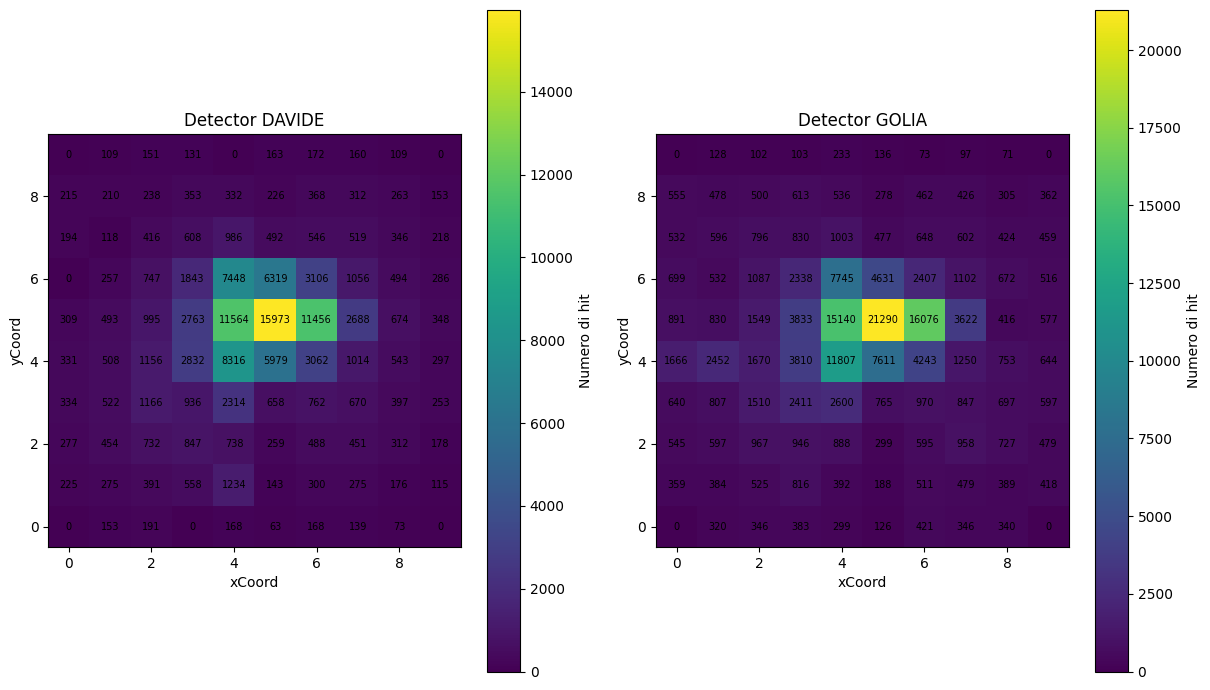

In [9]:
#plot heatmap of number of hits per xCoord and yCoord per detector

plt.figure(figsize=(18, 7))
for det in range(1, 3):
    plt.subplot(1, 3, det)
    df_det = df_good[df_good['Detector'] == det]
    heatmap = df_det.groupby(['xCoord', 'yCoord']).size().unstack(fill_value=0)
    plt.imshow(heatmap, origin='lower', cmap='viridis')
    for i in range(heatmap.shape[0]):
        for j in range(heatmap.shape[1]):
            plt.text(j, i, heatmap.iloc[i, j], ha='center', va='center', fontsize=7, color='black')
    plt.colorbar(label='Numero di hit')
    plt.title(f'Detector {titoli[det]}')
    plt.xlabel('xCoord')
    plt.ylabel('yCoord')
plt.tight_layout()
plt.show()

Attenzione: efficienza > 1 per canale (4, 5) - hits_det1: 1818, hits_det2: 2164
Attenzione: efficienza > 1 per canale (5, 5) - hits_det1: 6720, hits_det2: 6905
Efficiency for Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.45735027 0.9877451  0.41899441 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.57606491 0.54396423 0.73477311 1.19031903
  0.91924227 0.6686747  0.         0.        ]
 [0.         0.         0.5426009  0.60664336 0.78534323 1.02752976
  0.9305741  0.8633235  0.         0.        ]
 [0.         0.         0.         0.55238095 0.62557737 0.75154639
  0.61097852 0.60724234 0.         0.        ]
 [0.         0.         0.         0.       

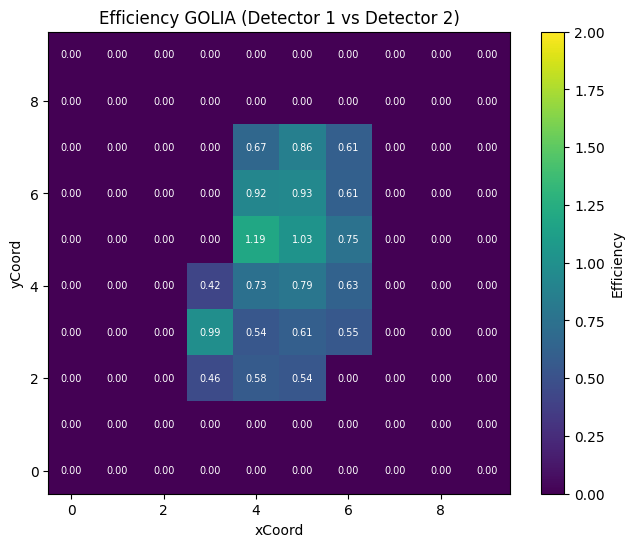

In [10]:
#efficienncy map per detector 1 e 2
# selection of events 1 hit per events on detector 1 no constraint on det 2
df_eff=df_good.copy()
df_eff = df_eff[(df_eff['Mult_det1'] == 1) & (df_eff['Mult_det2'] >= 0)]
# efficienza = numero eventi con hit in det 2 / numero totale eventi con hit in det 1
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            
            hits_det1 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 1)])
            hits_det2 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 2)])
            if hits_det2 < 200:
                continue
            efficiency[x, y] = hits_det2 / hits_det1 if hits_det1 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficiency for Davide:\n{efficiency}")
plt.figure(figsize=(8, 6))
plt.imshow(efficiency.T, origin='lower', cmap='viridis', vmin=0, vmax=2)
for x in range(10):
    for y in range(10):
        plt.text(x, y, f"{efficiency[x, y]:.2f}", ha='center', va='center', fontsize=7, color='white')
plt.colorbar(label='Efficiency')
plt.title('Efficiency GOLIA (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

Attenzione: efficienza > 1 per canale (3, 4) - hits_det1: 236, hits_det2: 228
Attenzione: efficienza > 1 per canale (4, 3) - hits_det1: 383, hits_det2: 356
Attenzione: efficienza > 1 per canale (6, 4) - hits_det1: 1603, hits_det2: 1365
Attenzione: efficienza > 1 per canale (6, 5) - hits_det1: 1049, hits_det2: 737
Efficienza per Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         1.03508772 0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         1.0758427  0.92616034 0.96878049
  0.90153846 0.         0.         0.        ]
 [0.         0.         0.         0.94785276 0.95731707 0.96822555
  0.92431193 0.93776824 0.         0.        ]
 [0.

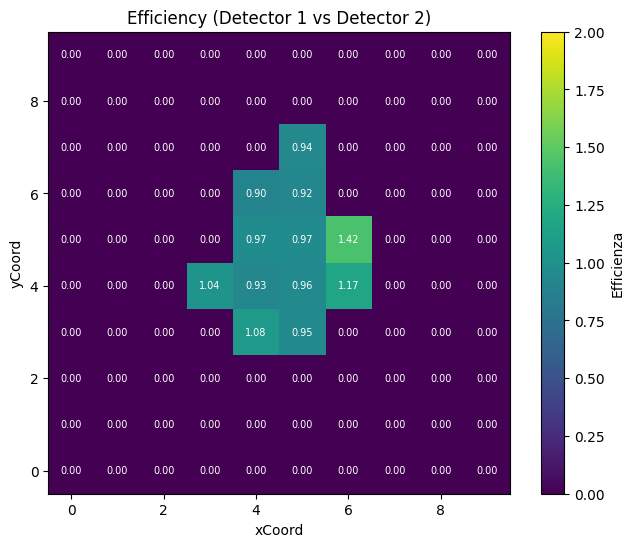

In [11]:
#efficienncy map per detector 1 e 2
# selection of events 1 hit per events on detector 1 no constraint on det 2
df_eff = df_good[(df_good['Mult_det1'] == 1) & (df_good['Mult_det2'] == 1)]
# efficienza = numero eventi con hit in det 2 / numero totale eventi con hit in det 1
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            hits_det1 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 1)])
            hits_det2 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 2)])
            if hits_det2 < 200:
                continue
            efficiency[x, y] = hits_det1 / hits_det2 if hits_det2 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Davide:\n{efficiency}")
plt.figure(figsize=(8, 6))
plt.imshow(efficiency.T, origin='lower', cmap='viridis', vmin=0, vmax=2)
for x in range(10):
    for y in range(10):
        plt.text(x, y, f"{efficiency[x, y]:.2f}", ha='center', va='center', fontsize=7, color='white')
plt.colorbar(label='Efficienza')
plt.title('Efficiency (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

Attenzione: efficienza > 1 per canale (6, 5) - hits_det1: 3408, hits_det2: 1883
Attenzione: efficienza > 1 per canale (6, 6) - hits_det1: 1353, hits_det2: 883
Efficiency for GOLIA:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.18489066 0.         0.        ]
 [0.         0.         0.46563574 0.25477707 0.52429668 0.
  0.         0.         0.         0.        ]
 [0.04893964 0.04899292 0.41301059 0.54939759 0.51434063 0.97330179
  0.69619464 0.         0.         0.        ]
 [0.         0.         0.43478261 0.51481274 0.64426975 0.75758078
  0.63212379 0.70338462 0.         0.        ]
 [0.         0.         0.         0.66585067 0.79519165 1.80987785
  1.53227633 0.         0.         0.        ]
 [0.         0.         0.         0.         

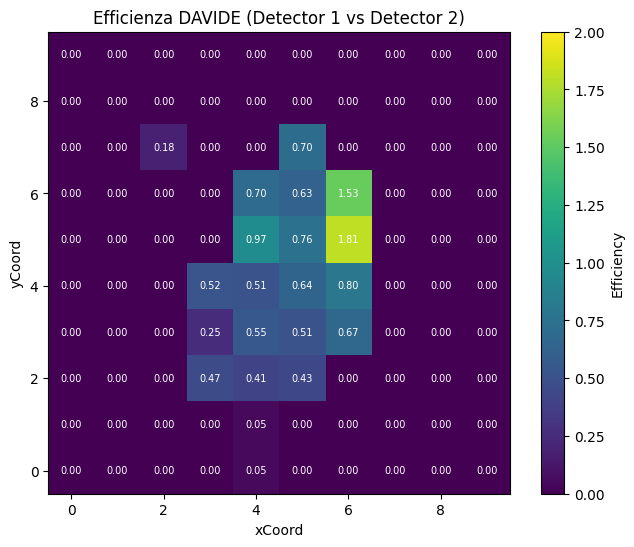

In [12]:
#efficienncy map per detector 1 e 2
# selection of events 1 hit per events on detector 1 no constraint on det 2
df_eff=df_good.copy()
df_eff = df_eff[(df_eff['Mult_det2'] == 1) & (df_eff['Mult_det1'] >= 0)]
# efficienza = numero eventi con hit in det 2 / numero totale eventi con hit in det 1
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            
            hits_det1 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 1)])
            hits_det2 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 2)])
            if hits_det2 < 500:
                continue
            efficiency[x, y] = hits_det1 / hits_det2 if hits_det2 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficiency for GOLIA:\n{efficiency}")
plt.figure(figsize=(8, 6))
plt.imshow(efficiency.T, origin='lower', cmap='viridis', vmin=0, vmax=2)
for x in range(10):
    for y in range(10):
        plt.text(x, y, f"{efficiency[x, y]:.2f}", ha='center', va='center', fontsize=7, color='white')
plt.colorbar(label='Efficiency')
plt.title('Efficienza DAVIDE (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

Attenzione: efficienza > 1 per canale (4, 4) - hits_det1: 1756, hits_det2: 1896
Attenzione: efficienza > 1 per canale (4, 5) - hits_det1: 993, hits_det2: 1025
Attenzione: efficienza > 1 per canale (4, 6) - hits_det1: 293, hits_det2: 325
Attenzione: efficienza > 1 per canale (5, 3) - hits_det1: 309, hits_det2: 326
Attenzione: efficienza > 1 per canale (5, 4) - hits_det1: 2355, hits_det2: 2460
Attenzione: efficienza > 1 per canale (5, 5) - hits_det1: 4327, hits_det2: 4469
Attenzione: efficienza > 1 per canale (5, 6) - hits_det1: 2821, hits_det2: 3052
Attenzione: efficienza > 1 per canale (5, 7) - hits_det1: 437, hits_det2: 466
Efficienza per Davide:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.        

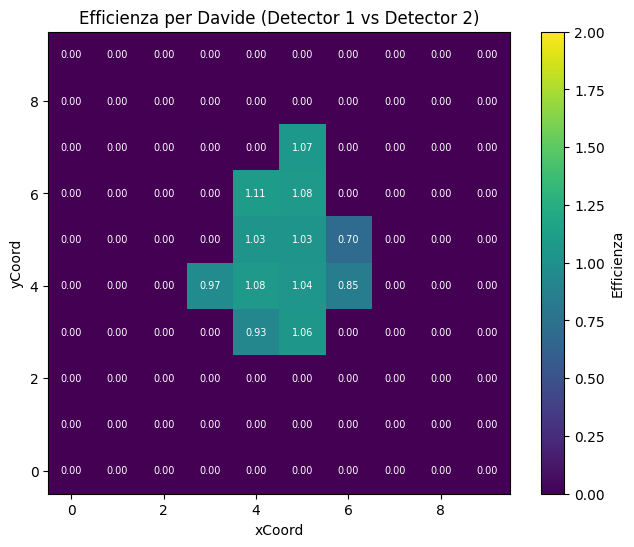

In [13]:
#efficienncy map per detector 1 e 2
# selection of events 1 hit per events on detector 1 no constraint on det 2
df_eff = df_good[(df_good['Mult_det1'] == 1) & (df_good['Mult_det2'] == 1)]
# efficienza = numero eventi con hit in det 2 / numero totale eventi con hit in det 1
efficiency = np.zeros((10, 10))  # matrice di efficienza per canale (x,y)
    
for x in range(10):
        for y in range(10):
            hits_det1 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 1)])
            hits_det2 = len(df_eff[(df_eff['xCoord'] == x) & (df_eff['yCoord'] == y) & (df_eff['Detector'] == 2)])
            if hits_det2 < 200:
                continue
            efficiency[x, y] = hits_det2 / hits_det1 if hits_det2 > 0 else 0
            
            if efficiency[x, y] > 1:
                print(f"Attenzione: efficienza > 1 per canale ({x}, {y}) - hits_det1: {hits_det1}, hits_det2: {hits_det2}")

print(f"Efficienza per Davide:\n{efficiency}")
plt.figure(figsize=(8, 6))
plt.imshow(efficiency.T, origin='lower', cmap='viridis', vmin=0, vmax=2)
for x in range(10):
    for y in range(10):
        plt.text(x, y, f"{efficiency[x, y]:.2f}", ha='center', va='center', fontsize=7, color='white')
plt.colorbar(label='Efficienza')
plt.title('Efficienza per Davide (Detector 1 vs Detector 2)')
plt.xlabel('xCoord')
plt.ylabel('yCoord')
#plt.grid()
plt.show()

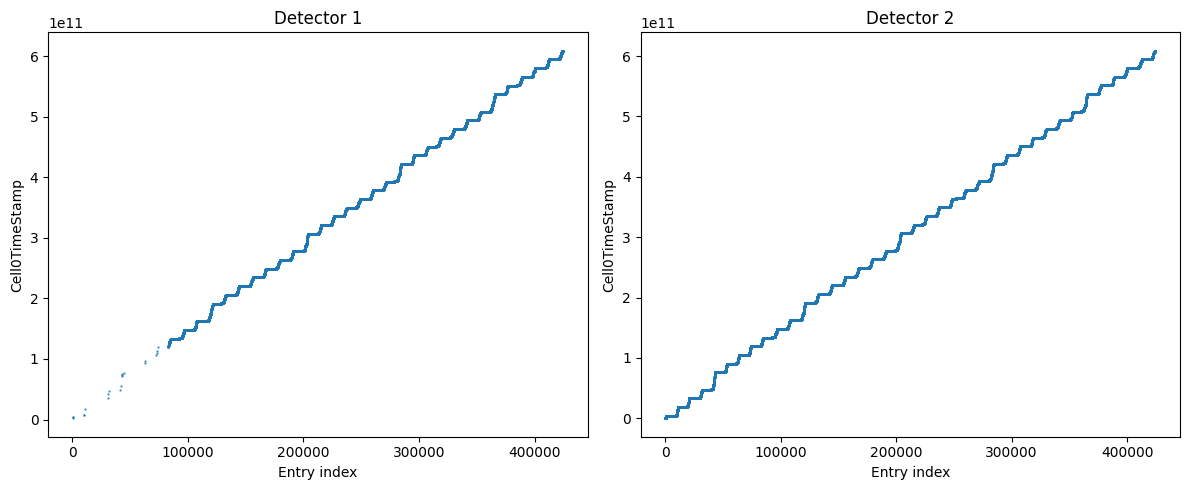

In [14]:
df_good = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, det in enumerate(range(1, 3)):
    df_det = df_good[df_good['Detector'] == det]
    axes[i].plot(df_det.index, df_det["Cell0TimeStamp"], '.', markersize=1)
    axes[i].set_title(f"Detector {det}")
    axes[i].set_xlabel("Entry index")
    axes[i].set_ylabel("Cell0TimeStamp")

plt.tight_layout()
plt.show()

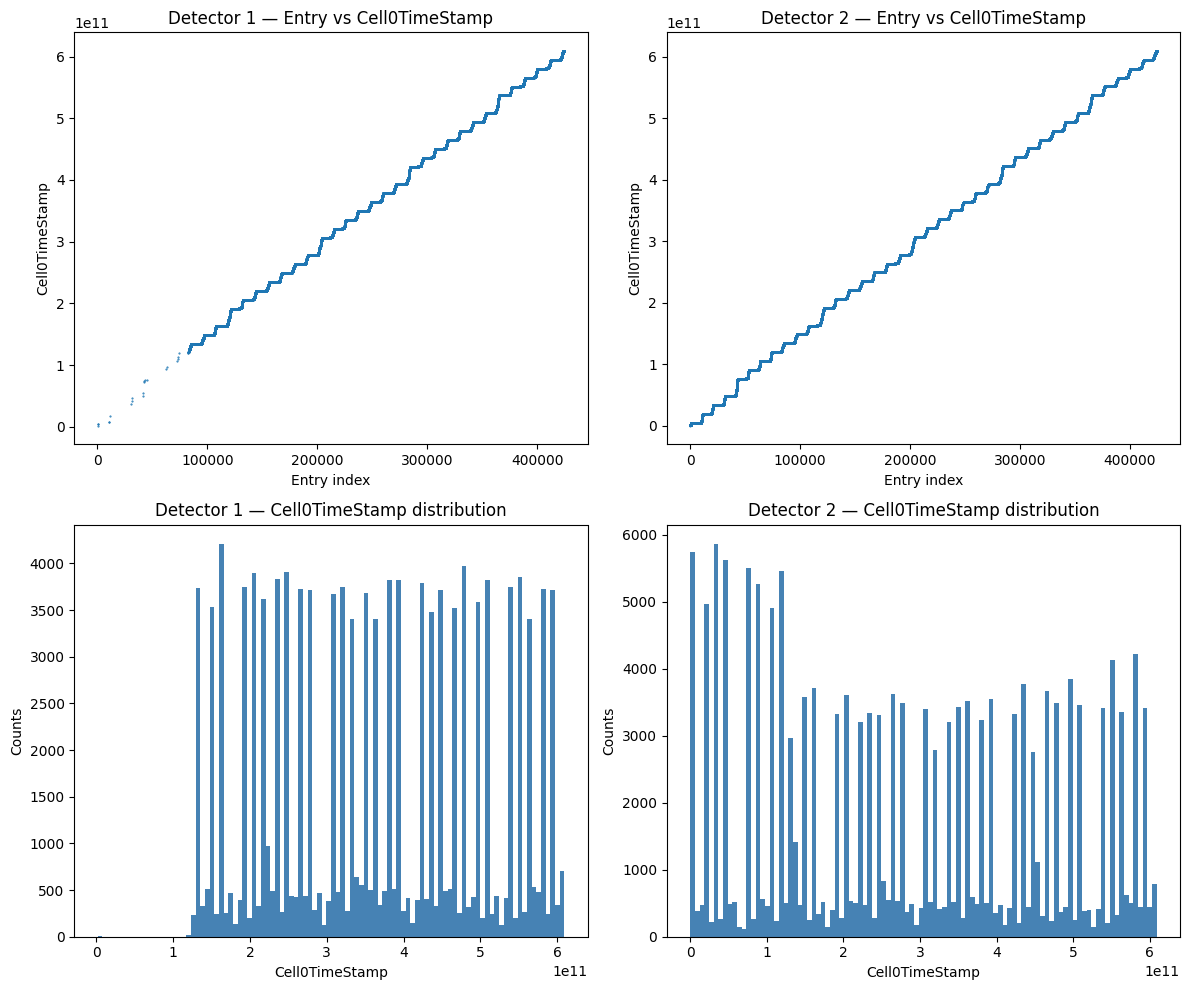

In [15]:
df_good = df.copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, det in enumerate(range(1, 3)):
    df_det = df_good[df_good['Detector'] == det]
    
    # Line plot
    axes[0, i].plot(df_det.index, df_det["Cell0TimeStamp"], '.', markersize=1)
    axes[0, i].set_title(f"Detector {det} — Entry vs Cell0TimeStamp")
    axes[0, i].set_xlabel("Entry index")
    axes[0, i].set_ylabel("Cell0TimeStamp")
    
    # Histogram
    axes[1, i].hist(df_det["Cell0TimeStamp"], bins=100, color='steelblue', edgecolor='none')
    axes[1, i].set_title(f"Detector {det} — Cell0TimeStamp distribution")
    axes[1, i].set_xlabel("Cell0TimeStamp")
    axes[1, i].set_ylabel("Counts")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from matplotlib.backends.backend_pdf import PdfPages

def polya_pdf(Q, Qbar, theta):
    Q = np.asarray(Q, dtype=float)
    norm = ((1 + theta) ** (1 + theta)) / (math.gamma(1 + theta) * Qbar)
    x = Q / Qbar
    return norm * (x ** theta) * np.exp(-(1 + theta) * x)

# --- Prepara dati ---
df_pic = df.copy()
df_pic['ampiezza'] = -df_pic['ampiezza']        # inverti segno se negativa
df_pic = df_pic[df_pic['ampiezza'] > 0]

risultati = []

with PdfPages('polya_ampiezza_per_canale.pdf') as pdf:
    for det in [1, 2]:
        df_det = df_pic[df_pic['Detector'] == det]

        canali_validi = (
            df_det.groupby(['xCoord', 'yCoord'])['ampiezza']
            .count()
            [lambda s: s >= 500]
            .index.tolist()
        )
        print(f"Detector {det} — canali validi: {len(canali_validi)}")

        for (xc, yc) in sorted(canali_validi):
            mask = (df_det['xCoord'] == xc) & (df_det['yCoord'] == yc)
            ampiezza = df_det[mask]['ampiezza'].values

            counts, bin_edges = np.histogram(ampiezza, bins=100, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            mask_nz = counts > 0

            p0 = [ampiezza.mean(), 1.0]
            fit_ok = False

            try:
                popt, pcov = curve_fit(
                    polya_pdf,
                    bin_centers[mask_nz],
                    counts[mask_nz],
                    p0=p0,
                    bounds=([0, 0], [np.inf, np.inf]),
                    maxfev=10000
                )
                Qbar_fit, theta_fit = popt
                perr = np.sqrt(np.diag(pcov))
                fit_ok = True
            except (RuntimeError, ValueError) as e:
                print(f"  Det{det} ({xc},{yc}): fit fallito — {e}")
                Qbar_fit, theta_fit = np.nan, np.nan
                perr = [np.nan, np.nan]

            risultati.append({
                'Detector': det,
                'xCoord': xc, 'yCoord': yc,
                'n_eventi': len(ampiezza),
                'Qbar': Qbar_fit, 'Qbar_err': perr[0],
                'theta': theta_fit, 'theta_err': perr[1],
                'fit_ok': fit_ok
            })

            fig, ax = plt.subplots(figsize=(8, 5))
            ax.hist(ampiezza, bins=100, density=True, alpha=0.7,
                    color='steelblue' if det == 1 else 'darkorange',
                    edgecolor='k', label=f'Dati (N={len(ampiezza)})')

            if fit_ok:
                x_fit = np.linspace(ampiezza.min(), ampiezza.max(), 1000)
                y_fit = polya_pdf(x_fit, Qbar_fit, theta_fit)
                ax.plot(x_fit, y_fit, 'r-', lw=2,
                        label=f'Pólya: $\\bar{{Q}}$={Qbar_fit:.1f}±{perr[0]:.1f}, '
                              f'$\\theta$={theta_fit:.2f}±{perr[1]:.2f}')
            else:
                ax.text(0.5, 0.6, 'Fit fallito', transform=ax.transAxes,
                        ha='center', color='red', fontsize=14)

            ax.set_xlabel('Ampiezza (ADC)')
            ax.set_ylabel('Densità')
            ax.set_title(f'PICOSEC Detector {det} — Canale ({xc}, {yc})')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

print("Salvato: polya_ampiezza_per_canale.pdf")

df_fit = pd.DataFrame(risultati)
print(df_fit.to_string())

Detector 1 — canali validi: 41
Detector 2 — canali validi: 65
Salvato: polya_ampiezza_per_canale.pdf
     Detector  xCoord  yCoord  n_eventi      Qbar  Qbar_err     theta  theta_err  fit_ok
0           1     1.0     3.0       642  0.024953  0.000879  5.217159   0.628101    True
1           1     1.0     4.0      1389  0.026510  0.000534  7.709462   0.680238    True
2           1     2.0     2.0       770  0.040082  0.001180  1.758344   0.195352    True
3           1     2.0     3.0       911  0.044123  0.001289  1.721674   0.197901    True
4           1     2.0     4.0       789  0.042510  0.001476  1.782627   0.241674    True
5           1     2.0     6.0       511  0.042740  0.001370  1.786843   0.229760    True
6           1     3.0     1.0       562  0.036082  0.001399  1.874964   0.265994    True
7           1     3.0     2.0      1219  0.038707  0.001399  1.706953   0.230107    True
8           1     3.0     3.0       994  0.067617  0.001921  5.486367   0.753561    True
9        

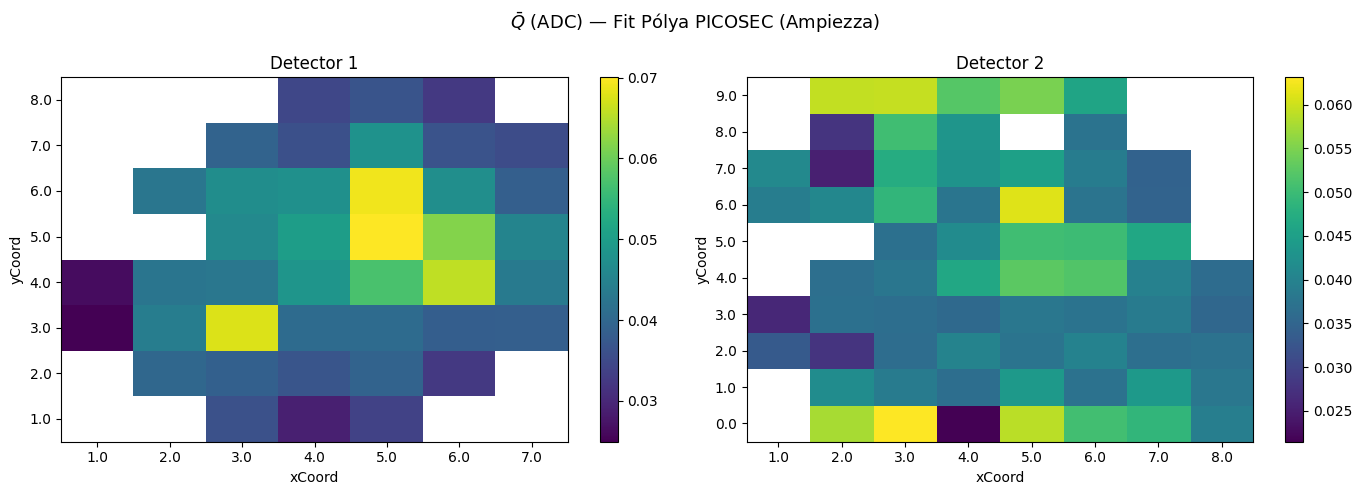

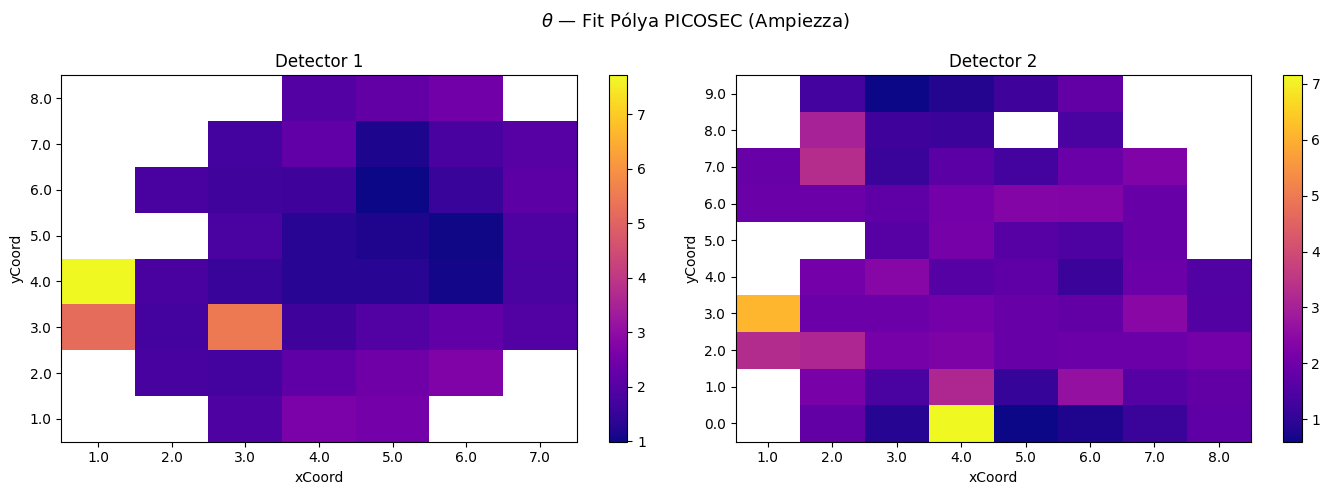

In [21]:
df_ok = df_fit[df_fit['fit_ok']]

for col, label, cmap in [('Qbar', '$\\bar{Q}$ (ADC)', 'viridis'),
                          ('theta', '$\\theta$', 'plasma')]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{label} — Fit Pólya PICOSEC (Ampiezza)', fontsize=13)

    for ax, det in zip(axes, [1, 2]):
        sub = df_ok[df_ok['Detector'] == det]
        if sub.empty:
            ax.set_visible(False)
            continue
        pivot = sub.pivot(index='yCoord', columns='xCoord', values=col)
        im = ax.imshow(pivot, origin='lower', aspect='auto', cmap=cmap)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('xCoord')
        ax.set_ylabel('yCoord')
        ax.set_title(f'Detector {det}')
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig(f'polya_heatmap_ampiezza_{col}.png', dpi=150)
    plt.show()